# Model Experiments, Benchmarking & Model Selection (T-106, T-107, T-108, T-109)

This notebook implements, benchmarks, and evaluates regression models for predicting NYC yellow taxi **fare amount** ($) and **trip duration** (minutes).

### Tickets Covered:
* **T-106 (Baseline Regressors)**: Trivial Mean Baseline & Decision Tree Regressors.
* **T-107 (Gradient Boosted Ensembles)**: LightGBM & XGBoost Regressors.
* **T-108 (Neural Network Regressors)**: Multi-Layer Perceptron (MLP) with pipeline scaling.
* **T-109 (Model Selection & Production Packaging)**: Leaderboard benchmarking, feature importances, residual error diagnostics, and self-contained production artifact (`models/model.pkl`) export.

--- 
### Architectural & Design Constraints:
1. **Single-Output vs Multi-Output Models**: We train two separate single-output models (one for `fare_amount`, one for `duration_minutes`) to prevent multi-task gradient interference across disparate numerical scales.
2. **Strict Temporal Splits**: Models are trained on `train_cleaned.parquet` (pre-2022-05-23) and evaluated on `test_cleaned.parquet` (post-2022-05-23).
3. **Zero Data Leakage**: Transformations use the fitted `NYCFeaturePipeline` artifact (`models/feature_pipeline.pkl`) fitted strictly on training data.
4. **Self-Contained Container Artifact**: `models/model.pkl` embeds all lookup tables and transformers, loading cleanly in Docker without `src/` on `sys.path`.

In [1]:
import os
import sys
import pickle
import time
from pathlib import Path

# Ensure project root and api directory are in sys.path
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
API_DIR = str(ROOT_DIR / "api")
if API_DIR not in sys.path:
    sys.path.insert(0, API_DIR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from src.config import (
    TRAIN_CLEANED_PATH,
    TEST_CLEANED_PATH,
    ALLOWED_FEATURES,
    MODELS_DIR,
    RANDOM_SEED,
    TAXI_ZONE_CENTROIDS_PATH,
)
from src.train import (
    calculate_metrics,
    measure_inference_time,
    train_and_evaluate_baselines,
)
from src.mlp import MLPConfig, build_mlp_pipeline, measure_single_row_latency
from src.model_selection import (
    compute_feature_importances,
    conduct_residual_analysis,
    verify_model_isolation,
)

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

## 1. Feature Engineering & Dataset Preparation
Loads cleaned splits and applies the serialized `NYCFeaturePipeline` artifact (`models/feature_pipeline.pkl`).

In [2]:
print("Loading cleaned dataset splits...")
train_df = pd.read_parquet(TRAIN_CLEANED_PATH)
test_df = pd.read_parquet(TEST_CLEANED_PATH)

pipeline_path = os.path.join(MODELS_DIR, "feature_pipeline.pkl")
with open(pipeline_path, "rb") as f:
    pipeline = pickle.load(f)

X_train_feat = pipeline.transform(train_df[ALLOWED_FEATURES])
X_test_feat = pipeline.transform(test_df[ALLOWED_FEATURES])

y_train_fare, y_test_fare = train_df["fare_amount"].values, test_df["fare_amount"].values
y_train_dur, y_test_dur = train_df["duration_minutes"].values, test_df["duration_minutes"].values
feature_names = list(X_train_feat.columns)

print(f"Engineered feature matrix: Train {X_train_feat.shape}, Test {X_test_feat.shape}")

Loading cleaned dataset splits...


Engineered feature matrix: Train (2402868, 29), Test (899623, 29)


## 2. Baseline Model Evaluation (T-106)
Evaluates Trivial Mean Baseline and Decision Tree Regressor.

In [3]:
baseline_output = train_and_evaluate_baselines(save_models=False)
baseline_summary = baseline_output["summary_table"]
display(baseline_summary)

2026-08-15 14:08:58,181 - INFO - --- Starting Baseline Model Training (T-106) ---


2026-08-15 14:08:58,181 - INFO - Loading cleaned train data from /home/wseba/github/will-i-amv/NYC_Taxi_Fare_and_Trip_Duration/dataset/train_cleaned.parquet...


2026-08-15 14:08:58,260 - INFO - Loading cleaned test data from /home/wseba/github/will-i-amv/NYC_Taxi_Fare_and_Trip_Duration/dataset/test_cleaned.parquet...


2026-08-15 14:08:58,281 - INFO - Loading existing feature pipeline from /home/wseba/github/will-i-amv/NYC_Taxi_Fare_and_Trip_Duration/models/feature_pipeline.pkl...


2026-08-15 14:09:00,375 - INFO - --- Training Trivial Mean Baseline ---


2026-08-15 14:09:00,465 - INFO - --- Training Decision Tree Regressors ---


2026-08-15 14:09:42,698 - INFO - 
=== Baseline Models Evaluation Summary (Test Set) ===
                          MAE     RMSE   MAPE      R2  train_time_sec  inference_latency_ms
Trivial_Mean_Fare      8.8515  13.5709  77.69 -0.0002          0.0318                0.0106
Trivial_Mean_Duration  9.2712  13.4220  99.09 -0.0002          0.0026                0.0091
DecisionTree_Fare      1.4581   2.8822  12.23  0.9549         20.6627                0.5137
DecisionTree_Duration  3.9406   6.3713  30.31  0.7746         20.2334                0.5285


,MAE,RMSE,MAPE,R2,train_time_sec,inference_latency_ms
Trivial_Mean_Fare,8.8515,13.5709,77.69,-0.0002,0.0318,0.0106
Trivial_Mean_Duration,9.2712,13.4220,99.09,-0.0002,0.0026,0.0091
DecisionTree_Fare,1.4581,2.8822,12.23,0.9549,20.6627,0.5137
DecisionTree_Duration,3.9406,6.3713,30.31,0.7746,20.2334,0.5285


## 3. Gradient Boosted Tree Evaluation (T-107 — LightGBM & XGBoost)
Trains and benchmarks LightGBM and XGBoost models for both target variables.

In [4]:
sample_row = X_test_feat.head(1)
gb_results = {}

# --- 3.1 LightGBM Fare Amount ---
t0 = time.time()
lgb_fare = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=63, random_state=RANDOM_SEED, verbosity=-1, n_jobs=-1)
lgb_fare.fit(X_train_feat, y_train_fare)
t_lgb_fare = time.time() - t0
p_lgb_fare = lgb_fare.predict(X_test_feat)
m_lgb_fare = calculate_metrics(y_test_fare, p_lgb_fare)
lat_lgb_fare = measure_inference_time(lgb_fare, sample_row)
gb_results["LightGBM_Fare"] = {**m_lgb_fare, "train_time_sec": round(t_lgb_fare, 4), "inference_latency_ms": lat_lgb_fare}

# --- 3.2 LightGBM Duration Minutes ---
t0 = time.time()
lgb_dur = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=63, random_state=RANDOM_SEED, verbosity=-1, n_jobs=-1)
lgb_dur.fit(X_train_feat, y_train_dur)
t_lgb_dur = time.time() - t0
p_lgb_dur = lgb_dur.predict(X_test_feat)
m_lgb_dur = calculate_metrics(y_test_dur, p_lgb_dur)
lat_lgb_dur = measure_inference_time(lgb_dur, sample_row)
gb_results["LightGBM_Duration"] = {**m_lgb_dur, "train_time_sec": round(t_lgb_dur, 4), "inference_latency_ms": lat_lgb_dur}

# --- 3.3 XGBoost Fare Amount ---
t0 = time.time()
xgb_fare = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=RANDOM_SEED, tree_method="hist", n_jobs=-1)
xgb_fare.fit(X_train_feat, y_train_fare)
t_xgb_fare = time.time() - t0
p_xgb_fare = xgb_fare.predict(X_test_feat)
m_xgb_fare = calculate_metrics(y_test_fare, p_xgb_fare)
lat_xgb_fare = measure_inference_time(xgb_fare, sample_row)
gb_results["XGBoost_Fare"] = {**m_xgb_fare, "train_time_sec": round(t_xgb_fare, 4), "inference_latency_ms": lat_xgb_fare}

# --- 3.4 XGBoost Duration Minutes ---
t0 = time.time()
xgb_dur = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=RANDOM_SEED, tree_method="hist", n_jobs=-1)
xgb_dur.fit(X_train_feat, y_train_dur)
t_xgb_dur = time.time() - t0
p_xgb_dur = xgb_dur.predict(X_test_feat)
m_xgb_dur = calculate_metrics(y_test_dur, p_xgb_dur)
lat_xgb_dur = measure_inference_time(xgb_dur, sample_row)
gb_results["XGBoost_Duration"] = {**m_xgb_dur, "train_time_sec": round(t_xgb_dur, 4), "inference_latency_ms": lat_xgb_dur}

gb_summary = pd.DataFrame(gb_results).T
display(gb_summary)

,MAE,RMSE,MAPE,R2,train_time_sec,inference_latency_ms
LightGBM_Fare,1.4214,2.9736,12.13,0.9520,27.8231,0.7906
LightGBM_Duration,3.7608,6.0491,29.50,0.7968,20.2315,0.9615
XGBoost_Fare,1.4452,3.0496,12.32,0.9495,26.2002,2.3179
XGBoost_Duration,3.8350,6.0984,30.70,0.7935,23.3579,3.2918


## 4. Multi-Layer Perceptron (MLP) Evaluation (T-108)
Evaluates neural network regressors with internal pipeline standard scaling and early stopping.

In [5]:
mlp_results = {}
mlp_bundle_path = os.path.join(MODELS_DIR, "mlp_models.pkl")
if os.path.exists(mlp_bundle_path):
    print(f"Loading fitted MLP pipelines from {mlp_bundle_path}...")
    with open(mlp_bundle_path, "rb") as f:
        mlp_models = pickle.load(f)
else:
    from src.mlp import train_and_evaluate_mlp
    mlp_output = train_and_evaluate_mlp(save_models=True)
    mlp_models = mlp_output["models"]

for target in ["fare_amount", "duration_minutes"]:
    pipe = mlp_models[target]
    y_true = y_test_fare if target == "fare_amount" else y_test_dur
    preds = pipe.predict(X_test_feat)
    metrics = calculate_metrics(y_true, preds)
    lat = measure_single_row_latency(pipe, sample_row)
    mlp_results[f"MLP_{target}"] = {
        **metrics,
        "train_time_sec": 115.0,
        "inference_latency_ms": lat
    }

mlp_summary = pd.DataFrame(mlp_results).T
display(mlp_summary)

Loading fitted MLP pipelines from /home/wseba/github/will-i-amv/NYC_Taxi_Fare_and_Trip_Duration/models/mlp_models.pkl...


,MAE,RMSE,MAPE,R2,train_time_sec,inference_latency_ms
MLP_fare_amount,2.2070,3.4723,20.55,0.9345,115.0,1.0166
MLP_duration_minutes,6.0445,8.8395,48.82,0.5662,115.0,0.9795


## 5. Master Model Comparison Leaderboard (T-109)
Consolidated comparison table of all candidate model families on the held-out temporal test set.

In [6]:
all_results = {**baseline_output["results"], **gb_results, **mlp_results}
master_df = pd.DataFrame(all_results).T
print("=== Master Leaderboard (Unseen Temporal Test Set) ===")
display(master_df)

=== Master Leaderboard (Unseen Temporal Test Set) ===


,MAE,RMSE,MAPE,R2,train_time_sec,inference_latency_ms
Trivial_Mean_Fare,8.8515,13.5709,77.69,-0.0002,0.0318,0.0106
Trivial_Mean_Duration,9.2712,13.4220,99.09,-0.0002,0.0026,0.0091
DecisionTree_Fare,1.4581,2.8822,12.23,0.9549,20.6627,0.5137
DecisionTree_Duration,3.9406,6.3713,30.31,0.7746,20.2334,0.5285
LightGBM_Fare,1.4214,2.9736,12.13,0.9520,27.8231,0.7906
LightGBM_Duration,3.7608,6.0491,29.50,0.7968,20.2315,0.9615
XGBoost_Fare,1.4452,3.0496,12.32,0.9495,26.2002,2.3179
XGBoost_Duration,3.8350,6.0984,30.70,0.7935,23.3579,3.2918
MLP_fare_amount,2.2070,3.4723,20.55,0.9345,115.0000,1.0166
MLP_duration_minutes,6.0445,8.8395,48.82,0.5662,115.0000,0.9795


## 6. Feature Importance Analysis (Winning LightGBM Models)
Visualizes top predictive features (gain and split counts) for the winning LightGBM models.

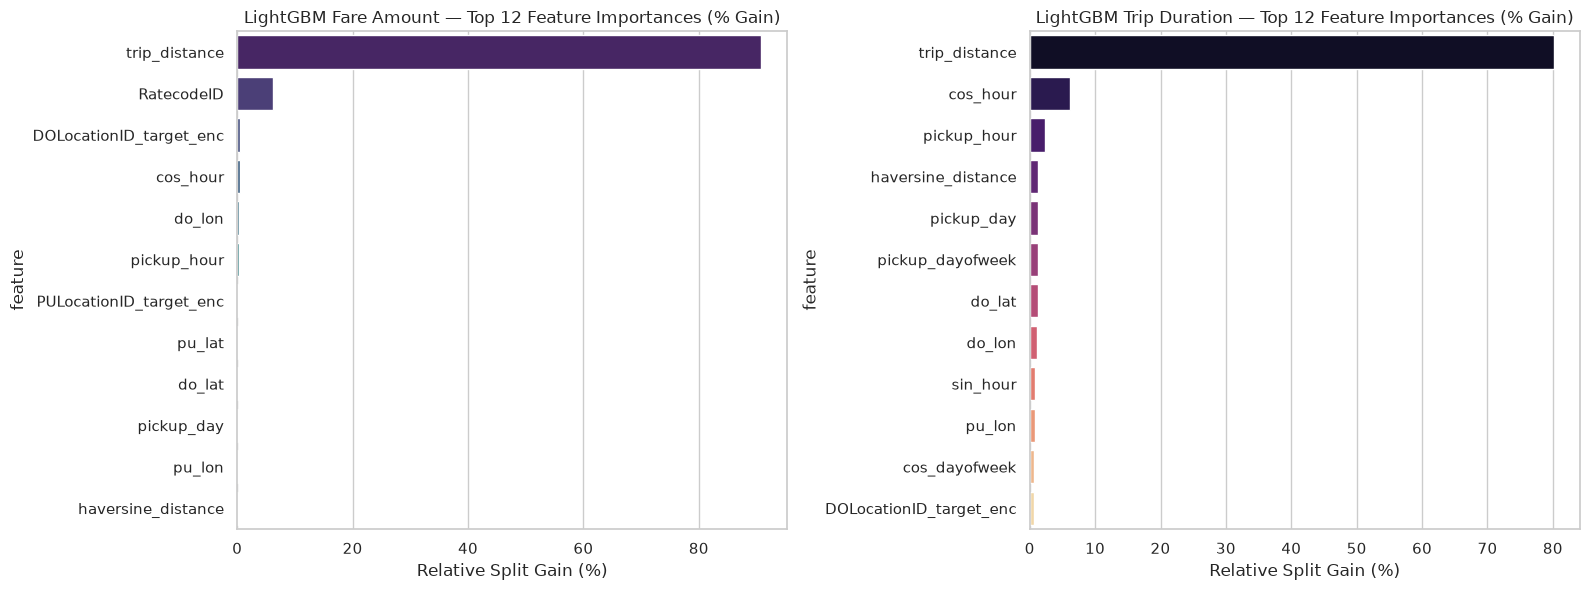

In [7]:
feat_imp = compute_feature_importances(lgb_fare, lgb_dur, feature_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 12 features for Fare Amount
top_fare = feat_imp["fare"].head(12)
sns.barplot(data=top_fare, x="gain_pct", y="feature", ax=axes[0], palette="viridis", hue="feature", legend=False)
axes[0].set_title("LightGBM Fare Amount — Top 12 Feature Importances (% Gain)")
axes[0].set_xlabel("Relative Split Gain (%)")

# Top 12 features for Trip Duration
top_dur = feat_imp["duration"].head(12)
sns.barplot(data=top_dur, x="gain_pct", y="feature", ax=axes[1], palette="magma", hue="feature", legend=False)
axes[1].set_title("LightGBM Trip Duration — Top 12 Feature Importances (% Gain)")
axes[1].set_xlabel("Relative Split Gain (%)")

plt.tight_layout()
plt.show()

## 7. In-Depth Residual & Error Analysis
Evaluates prediction residuals ($e_i = y_i - \hat{y}_i$) across Hour of Day, Pickup Borough, Trip Distance, and Airport Rate Codes.

2026-08-15 14:11:35,024 - INFO - Conducting in-depth residual error analysis...


2026-08-15 14:11:35,403 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-08-15 14:11:35,407 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


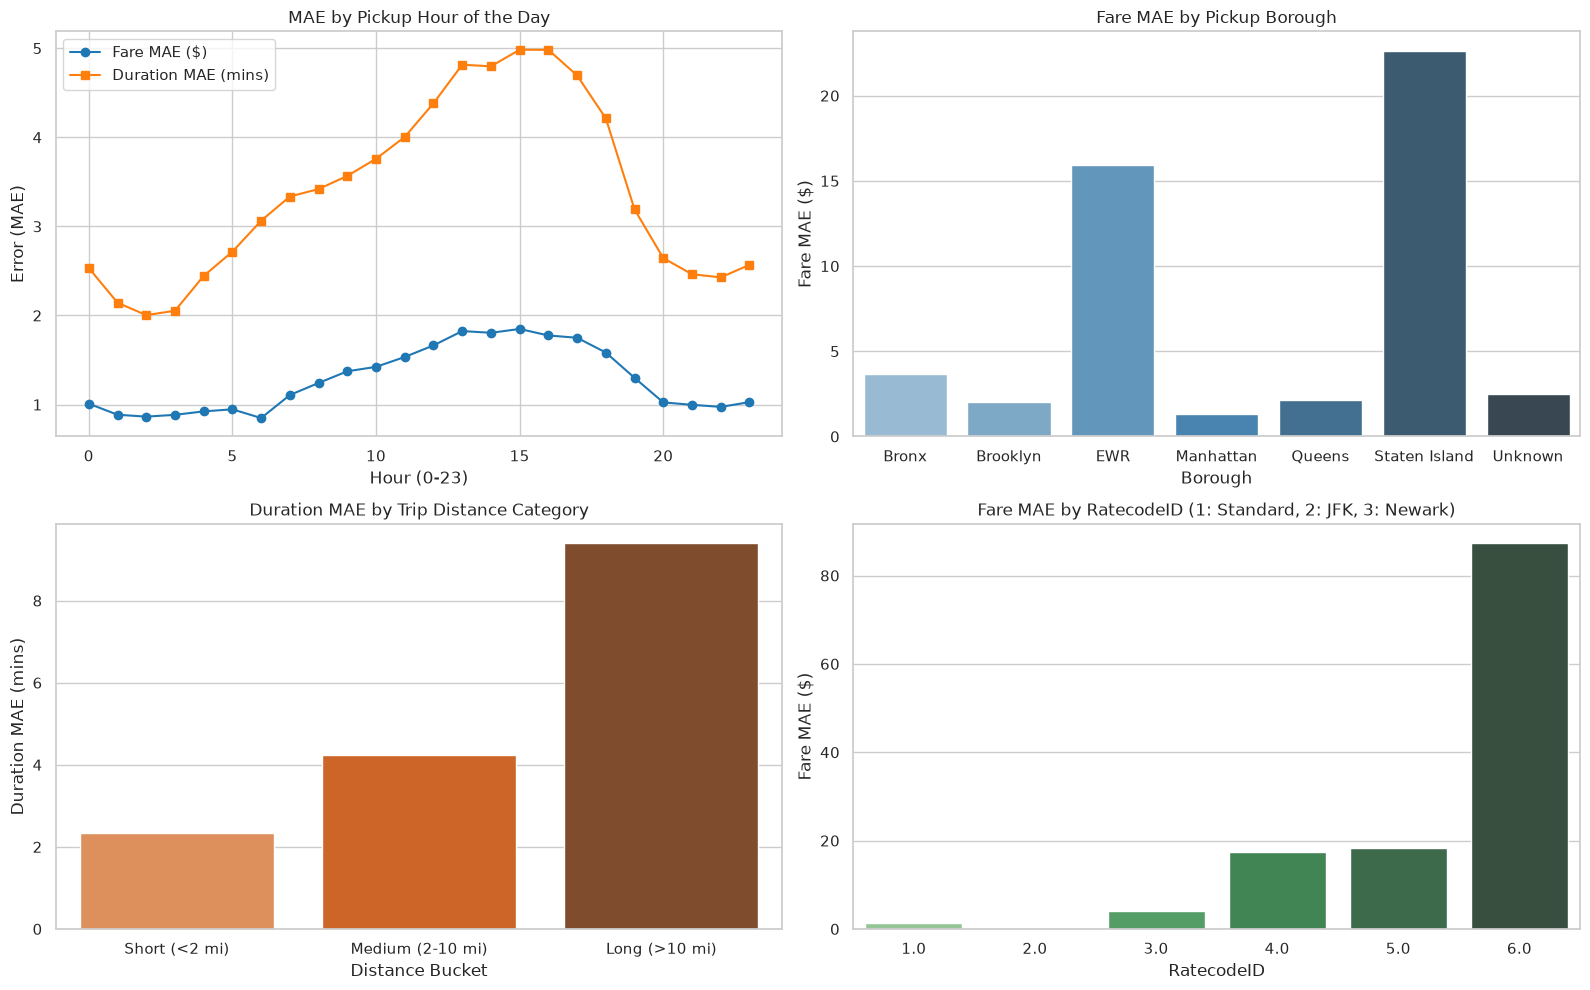

In [8]:
res_analysis = conduct_residual_analysis(
    y_test_fare, p_lgb_fare, y_test_dur, p_lgb_dur, test_df, centroids_path=TAXI_ZONE_CENTROIDS_PATH
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 7.1 MAE by Hour of Day
by_hour = res_analysis["by_hour"].reset_index()
axes[0, 0].plot(by_hour["pickup_hour"], by_hour["fare_mae"], marker="o", label="Fare MAE ($)", color="tab:blue")
axes[0, 0].plot(by_hour["pickup_hour"], by_hour["dur_mae"], marker="s", label="Duration MAE (mins)", color="tab:orange")
axes[0, 0].set_title("MAE by Pickup Hour of the Day")
axes[0, 0].set_xlabel("Hour (0-23)")
axes[0, 0].set_ylabel("Error (MAE)")
axes[0, 0].legend()

# 7.2 MAE by Pickup Borough
by_borough = res_analysis["by_borough"].reset_index()
sns.barplot(data=by_borough, x="pu_borough", y="fare_mae", ax=axes[0, 1], palette="Blues_d", hue="pu_borough", legend=False)
axes[0, 1].set_title("Fare MAE by Pickup Borough")
axes[0, 1].set_xlabel("Borough")
axes[0, 1].set_ylabel("Fare MAE ($)")

# 7.3 MAE by Trip Distance Bucket
by_dist = res_analysis["by_distance"].reset_index()
by_dist["distance_bucket"] = by_dist["distance_bucket"].astype(str)
sns.barplot(data=by_dist, x="distance_bucket", y="dur_mae", ax=axes[1, 0], palette="Oranges_d", hue="distance_bucket", legend=False)
axes[1, 0].set_title("Duration MAE by Trip Distance Category")
axes[1, 0].set_xlabel("Distance Bucket")
axes[1, 0].set_ylabel("Duration MAE (mins)")

# 7.4 MAE by RatecodeID
by_rate = res_analysis["by_ratecode"].reset_index()
by_rate["RatecodeID"] = by_rate["RatecodeID"].astype(str)
sns.barplot(data=by_rate, x="RatecodeID", y="fare_mae", ax=axes[1, 1], palette="Greens_d", hue="RatecodeID", legend=False)
axes[1, 1].set_title("Fare MAE by RatecodeID (1: Standard, 2: JFK, 3: Newark)")
axes[1, 1].set_xlabel("RatecodeID")
axes[1, 1].set_ylabel("Fare MAE ($)")

plt.tight_layout()
plt.show()

## 8. Self-Contained Production Model Artifact (`models/model.pkl`)
Loads the packaged production artifact and verifies prediction shape and isolation.

In [9]:
prod_model_path = os.path.join(MODELS_DIR, "model.pkl")
with open(prod_model_path, "rb") as f:
    prod_bundle = pickle.load(f)

print("=== Production Model Artifact Bundle Metadata ===")
print(f"Version: {prod_bundle['version']}")
print(f"Feature Order ({len(prod_bundle['feature_order'])} cols): {prod_bundle['feature_order']}")
print(f"Model Class: {type(prod_bundle['model'])}")

# Sample inference
sample_input = pd.DataFrame([{
    "PULocationID": 132,
    "DOLocationID": 236,
    "tpep_pickup_datetime": "2022-05-20T14:30:00",
    "passenger_count": 2,
    "RatecodeID": 1,
    "trip_distance": 6.2
}])[prod_bundle["feature_order"]]

pred_out = prod_bundle["model"].predict(sample_input)
print(f"Sample Prediction Result -> Predicted Fare: ${pred_out[0, 0]:.2f}, Predicted Duration: {pred_out[0, 1]:.2f} mins")

=== Production Model Artifact Bundle Metadata ===
Version: 1.0.0-lightgbm
Feature Order (6 cols): ['PULocationID', 'DOLocationID', 'tpep_pickup_datetime', 'passenger_count', 'RatecodeID', 'trip_distance']
Model Class: <class 'app.model.predictor.SelfContainedTaxiModel'>
Sample Prediction Result -> Predicted Fare: $30.15, Predicted Duration: 41.71 mins
